# 4 · Exploración y preparación de features

Esta notebook funciona como **puente entre la depuración reproducible y el modelado posterior**. Su objetivo es dejar evidencia clara de cómo pasamos de datasets ya auditados a una unidad analítica `zona-fecha` defendible, interpretable y lista para construir variables supervisadas.

A diferencia del informe final, acá el foco está puesto en la **lectura exploratoria y metodológica**: revisar calidad, cobertura, relaciones sustantivas y transformación de capas, sin duplicar la narrativa completa del trabajo.

## Resumen ejecutivo

- Se parte de reclamos ya limpiados temporal y geográficamente, con auditoría explícita de exclusiones.
- La lluvia se alinea a un calendario completo y se incorpora como contexto diario, incluyendo estado de observación y marca de evento intenso.
- El pipeline deja cuatro hitos fáciles de defender: `reclamos_clean` → `reclamos_zonificados` → `zona_diario_base` → `zona_diario_supervisado`.
- El resultado final conserva historial por zona, agrega lags/rolling usando solo pasado y define targets `t+1` sin entrenar todavía ningún modelo.

> Alcance de esta notebook: **exploración, calidad de datos y preparación**.  
> Fuera de alcance: selección final de modelo, entrenamiento y evaluación.


In [1]:
from pathlib import Path
import sys

import folium
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from folium.plugins import MarkerCluster
from IPython.display import Markdown, display

candidate_roots = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(path.resolve() for path in candidate_roots if (path / 'helpers').exists() and (path / 'data').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from helpers.eda_utils import (
    build_dataset_inventory,
    categorical_profile,
    dataset_overview,
    load_dataset,
    numeric_profile,
    preparation_trace,
    prepare_zone_map_dataset,
    quality_profile,
    read_report,
    supervised_feature_inventory,
)

pd.set_option('display.max_columns', 120)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda value: f'{value:,.2f}')
sns.set_theme(style='whitegrid', context='talk')
PROJECT_ROOT


PosixPath('/home/martin/Code/tp-ceia-amq')

## 1. Fuentes, preguntas y criterio de lectura

Antes de mirar gráficos conviene fijar **qué queremos defender**:

1. **Calidad y trazabilidad**: qué datasets participan y qué auditorías respaldan la limpieza.
2. **Cobertura analítica**: cuántas zonas/días quedan disponibles y qué rango temporal cubren.
3. **Relaciones sustantivas**: cómo dialogan lluvia, volumen de reclamos, costo y heterogeneidad espacial.
4. **Preparación para modelado**: qué columnas se agregan recién en `zona_diario_supervisado` y por qué eso deja un dataset utilizable para la siguiente etapa.

La idea NO es mostrar todo; es mostrar lo necesario para que el pipeline sea **creíble, simple y explicable**.


In [2]:
inventory = build_dataset_inventory([
    'reclamos_clean',
    'reclamos_zonificados',
    'lluvia_diaria_clean',
    'exclusiones_reclamos',
    'exclusiones_lluvia',
    'tramites_temporal_audit',
    'zona_diario_base',
    'zona_diario_supervisado',
])
display(inventory)

report_names = [
    'phase2_cleaning_audit',
    'phase3_rainfall_audit',
    'rain_feature_notes',
    'zona_diario_build_summary',
]
for report_name in report_names:
    display(Markdown(f'### {report_name}'))
    display(Markdown(read_report(report_name)))


,dataset,path,exists,size_mb
0,exclusiones_lluvia,intermediate/exclusiones_lluvia.parquet,True,0.01
1,exclusiones_reclamos,intermediate/exclusiones_reclamos.parquet,True,7.93
2,lluvia_diaria_clean,processed/lluvia_diaria_clean.parquet,True,0.03
3,reclamos_clean,processed/reclamos_clean.parquet,True,6.38
4,reclamos_zonificados,processed/reclamos_zonificados.parquet,True,10.17
5,tramites_temporal_audit,intermediate/tramites_temporal_audit.parquet,True,0.00
6,zona_diario_base,processed/zona_diario_base.parquet,True,1.75
7,zona_diario_supervisado,processed/zona_diario_supervisado.parquet,True,4.96


### phase2_cleaning_audit

# Auditoría de depuración — Phase 2

## Regla temporal canónica de `tramites`

- Fuente temporal canónica: `dt_inicio`.
- Regla explícita: conservar solo reclamos con `dt_inicio` entre `2021-01-01 00:00:00` y `2026-03-31 23:59:59` inclusive.
- Auditoría temporal: `16` filas difieren contra `fechainicio` + `horainicio`; se conserva `dt_inicio` por consistencia y cobertura completa.

## Regla geográfica

- Bounds válidos: latitud `-30.0` a `-25.0`, longitud `-57.0` a `-53.0`.
- Se detectaron `718` reclamos con columnas `geo1`/`geo2` invertidas y se corrigieron antes de persistir `lat`/`lon`.

## Resultados

- Reclamos totales analizados: `372551`.
- Reclamos retenidos en `data/processed/reclamos_clean.parquet`: `159030`.
- Reclamos excluidos en `data/intermediate/exclusiones_reclamos.parquet`: `213521`.
- Tareas retenidas en `data/processed/tareas_clean.parquet`: `254`.
- Tareas excluidas en `data/intermediate/exclusiones_tareas.parquet`: `325`.
- Destinos únicos para ruteo en `data/processed/destinos_unicos.parquet`: `14774`.

## Exclusiones de reclamos por motivo

- `duplicate_reclamo_id`: `14`
- `fecha_fuera_rango_lluvias`: `188879`
- `geo_missing_or_non_numeric`: `24626`
- `geo_zero_placeholder`: `2`

## Exclusiones de tareas por motivo

- `tarea_huerfana_sin_reclamo_clean`: `325`

## Mapeo reclamo ↔ tarea

- Clave de enlace retenida: `reclamo_id = NumeroTramite-NumeroOrden`.
- En tareas se mapeó `codigotar -> tarea_id`, `fecha/hora -> fecha_tarea` y `tarea -> tipo_tarea`.
- Solo se retienen tareas cuyo `reclamo_id` existe en `reclamos_clean`.

## Outputs generados

- `data/intermediate/exclusiones_reclamos.parquet`
- `data/intermediate/exclusiones_tareas.parquet`
- `data/intermediate/tramites_temporal_audit.parquet`
- `data/processed/reclamos_clean.parquet`
- `data/processed/tareas_clean.parquet`
- `data/processed/destinos_unicos.parquet`


### phase3_rainfall_audit

# Auditoría de lluvia diaria — Phase 3

## Regla de normalización

- Ventana retenida: `2021-01-01` → `2026-03-31` inclusive.
- La fecha final se construye desde `año_extraido` + `mes_extraido` + `dia`.
- Se excluyen meses inválidos, fechas imposibles, lluvia no numérica/negativa y filas fuera de rango.
- `lluvia_diaria_clean.parquet` queda alineado a calendario completo; los huecos se marcan `missing_source` sin inventar `lluvia_mm`.

## Resultados

- Filas crudas analizadas: `2012`.
- Filas excluidas a auditoría: `96`.
- Días observados dentro del rango: `1916`.
- Días calendario persistidos: `1916`.
- Días sin observación (`missing_source`): `0`.
- Días con duplicados colapsados: `0`.

## Fuente reproducible

- Input OCR base: `/home/martin/Code/tp-ceia-amq/data/raw/rain/dataset_lluvias_diario_con_obs.csv`.
- Input manual de recuperación: `/home/martin/Code/tp-ceia-amq/data/raw/rain/rainfall_manual_recovered_months.csv`.
- Filas manuales cargadas: `182`.
- Filas efectivamente aplicadas sobre el input base: `152`.
- Documentos recuperados manualmente: `11. Registro de lluvia 11-25.pdf, 8. Registro de lluvia 08-2025.pdf, 9. Registro de lluvia 09-2025.pdf, Registro lluvias 08-2022.pdf, Registro lluvias 09-2022.pdf, registro 04-2022.jpg`.

## Exclusiones por motivo

- `fecha_fuera_rango_modelado`: `62`
- `fecha_invalida`: `33`
- `mes_invalido`: `1`

## Outputs generados

- `data/raw/rain/rainfall_manual_recovered_months.csv`
- `data/processed/lluvia_diaria_clean.parquet`
- `data/intermediate/exclusiones_lluvia.parquet`
- `data/intermediate/lluvia_diaria_observada.parquet`


### rain_feature_notes

# Notas de features de lluvia

## Exploración de `observacion_codigo`

- Se normalizó `observacion_codigo` a cuatro categorías simples: `plain_a`, `missing`, `marca_horaria`, `evento_intenso`, más `otro_codigo` como residual.
- Se acepta `obs_evento_intenso_flag` porque la categoría `evento_intenso` concentra `462` días, con lluvia media `13.14 mm` y `287` días lluviosos, claramente por encima de `plain_a`/`missing`.
- Se rechazan one-hot por token individual (`B`, `R`, `•`, `°`, etc.) porque son más opacos y dispersos para esta etapa base.

## Resumen por categoría

| categoria | dias | dias_con_lluvia | lluvia_media_mm | lluvia_mediana_mm |
|---|---:|---:|---:|---:|
| `plain_a` | 856 | 145 | 3.59 | 0.00 |
| `evento_intenso` | 462 | 287 | 13.14 | 3.35 |
| `missing` | 253 | 56 | 3.21 | 0.00 |
| `marca_horaria` | 219 | 39 | 1.69 | 0.00 |
| `otro_codigo` | 126 | 48 | 7.05 | 0.00 |


### zona_diario_build_summary

# Resumen de construcción `zona-diario`

- Filas `zona_diario_base`: `75494`.
- Filas `zona_diario_supervisado`: `75494`.
- Zonas únicas: `43`.
- Rango temporal base: `2021-01-01` → `2026-03-31`.
- Días con reclamos: `25791`.
- Días sin reclamos pero retenidos para historial/targets: `49703`.

## Features iniciales incluidas

- Traslado: `traslado_min_total`, `traslado_min_promedio`, `distance_km_total`.
- Resolución heurística: `resolucion_base_min_total`, `tiempo_total_operativo_min`.
- Costo soporte: componentes laborales, km, combustible y `costo_total_compuesto_ars`.
- Lluvia: `llovio`, `lluvia_mm`, `lluvia_intensidad`, `lluvia_status`, `obs_evento_intenso_flag`.
- Supervisión futura: `y_tiempo_t+1_min`, `y_costo_t+1_ars`, `y_reclamos_t+1`.


## 2. Carga de datasets principales

Trabajamos con cuatro capas analíticas:

- **`reclamos_clean`**: reclamos válidos en tiempo y geografía.
- **`reclamos_zonificados`**: reclamos enriquecidos con zona, distancia, tiempos y costo compuesto.
- **`zona_diario_base`**: calendario completo por zona-fecha, incluso cuando no hubo reclamos.
- **`zona_diario_supervisado`**: mismo eje temporal, pero con rezagos, rolling means y targets `t+1`.


In [3]:
reclamos_clean = load_dataset('reclamos_clean')
reclamos_zonificados = load_dataset('reclamos_zonificados')
lluvia = load_dataset('lluvia_diaria_clean')
zona_diario_base = load_dataset('zona_diario_base')
zona_diario_supervisado = load_dataset('zona_diario_supervisado')
exclusiones_reclamos = load_dataset('exclusiones_reclamos')
exclusiones_lluvia = load_dataset('exclusiones_lluvia')
tramites_temporal_audit = load_dataset('tramites_temporal_audit')

final_dataset = zona_diario_supervisado.loc[zona_diario_supervisado['target_available_t+1']].copy()

datasets = {
    'reclamos_clean': reclamos_clean,
    'reclamos_zonificados': reclamos_zonificados,
    'lluvia_diaria_clean': lluvia,
    'zona_diario_base': zona_diario_base,
    'zona_diario_supervisado': zona_diario_supervisado,
}


## 3. Resumen ejecutivo de hallazgos

Arrancamos por una vista corta: cuánto se retuvo, cuánto calendario quedó cubierto y qué volumen efectivo queda listo para modelado. Esto ayuda a contar la película completa antes de entrar en los detalles.


In [4]:
overview = pd.concat([dataset_overview(df, name) for name, df in datasets.items()], ignore_index=True)
display(overview)

claims_total = int(len(reclamos_clean) + len(exclusiones_reclamos))
rain_total = int(len(lluvia) + len(exclusiones_lluvia))

pipeline_summary = pd.DataFrame([
    {
        'stage': 'reclamos_clean',
        'rows': int(len(reclamos_clean)),
        'share_vs_claims_input_pct': round(100 * len(reclamos_clean) / claims_total, 2),
        'comment': 'Reclamos retenidos luego de reglas temporales y geográficas.',
    },
    {
        'stage': 'reclamos_zonificados',
        'rows': int(len(reclamos_zonificados)),
        'share_vs_claims_input_pct': round(100 * len(reclamos_zonificados) / claims_total, 2),
        'comment': 'Misma base analítica con enriquecimiento espacial/operativo.',
    },
    {
        'stage': 'zona_diario_base',
        'rows': int(len(zona_diario_base)),
        'share_vs_claims_input_pct': None,
        'comment': 'Calendario zona-fecha completo, con días sin reclamos preservados.',
    },
    {
        'stage': 'zona_diario_supervisado listo',
        'rows': int(len(final_dataset)),
        'share_vs_claims_input_pct': None,
        'comment': 'Filas con target t+1 disponible y features temporales construidas.',
    },
])

audit_headlines = pd.DataFrame([
    {'metric': 'reclamos analizados', 'value': claims_total},
    {'metric': 'reclamos excluidos', 'value': int(len(exclusiones_reclamos))},
    {'metric': 'días de lluvia calendario', 'value': int(len(lluvia))},
    {'metric': 'días de lluvia excluidos', 'value': int(len(exclusiones_lluvia))},
    {'metric': 'zonas únicas', 'value': int(zona_diario_supervisado['zona_id'].nunique())},
    {'metric': 'filas listas para modelado', 'value': int(len(final_dataset))},
])

coverage_summary = pd.DataFrame([
    {
        'metric': 'rango reclamos_clean',
        'value': f"{pd.to_datetime(reclamos_clean['fecha_reclamo']).min().date()} → {pd.to_datetime(reclamos_clean['fecha_reclamo']).max().date()}"
    },
    {
        'metric': 'rango lluvia',
        'value': f"{pd.to_datetime(lluvia['fecha']).min().date()} → {pd.to_datetime(lluvia['fecha']).max().date()}"
    },
    {
        'metric': 'rango zona_diario_supervisado',
        'value': f"{pd.to_datetime(zona_diario_supervisado['fecha']).min().date()} → {pd.to_datetime(zona_diario_supervisado['fecha']).max().date()}"
    },
    {
        'metric': 'filas sin reclamos preservadas en base',
        'value': int((~zona_diario_base['has_claims']).sum()) if 'has_claims' in zona_diario_base.columns else None,
    },
])

display(Markdown('### Pipeline en una tabla'))
display(pipeline_summary)

display(Markdown('### Titulares para exposición'))
display(audit_headlines)

display(Markdown('### Cobertura temporal y analítica'))
display(coverage_summary)


,dataset,rows,columns,date_column,date_min,date_max,duplicated_rows
0,reclamos_clean,159030,15,fecha_reclamo,2021-01-01 05:14:00,2026-03-31 23:55:00,0
1,reclamos_zonificados,159030,46,fecha,2021-01-01 00:00:00,2026-03-31 00:00:00,0
2,lluvia_diaria_clean,1916,6,fecha,2021-01-01 00:00:00,2026-03-31 00:00:00,0
3,zona_diario_base,75494,49,fecha,2021-01-01 00:00:00,2026-03-31 00:00:00,0
4,zona_diario_supervisado,75494,73,fecha,2021-01-01 00:00:00,2026-03-31 00:00:00,0


### Pipeline en una tabla

,stage,rows,share_vs_claims_input_pct,comment
0,reclamos_clean,159030,42.69,Reclamos retenidos luego de reglas temporales ...
1,reclamos_zonificados,159030,42.69,Misma base analítica con enriquecimiento espac...
2,zona_diario_base,75494,NaN,"Calendario zona-fecha completo, con días sin r..."
3,zona_diario_supervisado listo,75451,NaN,Filas con target t+1 disponible y features tem...


### Titulares para exposición

,metric,value
0,reclamos analizados,372551
1,reclamos excluidos,213521
2,días de lluvia calendario,1916
3,días de lluvia excluidos,96
4,zonas únicas,43
5,filas listas para modelado,75451


### Cobertura temporal y analítica

,metric,value
0,rango reclamos_clean,2021-01-01 → 2026-03-31
1,rango lluvia,2021-01-01 → 2026-03-31
2,rango zona_diario_supervisado,2021-01-01 → 2026-03-31
3,filas sin reclamos preservadas en base,49703


## 4. Calidad de datos y reglas de limpieza defendibles

Acá importa mostrar que la preparación no fue “mágica” ni cosmética. La defensa pasa por tres ideas:

- las exclusiones tienen **motivo explícito**,
- la consistencia estructural se puede verificar con checks simples,
- y los targets nulos que quedan son **esperados** por construcción temporal, no errores de calidad.


In [5]:
reclamos_quality = quality_profile(reclamos_zonificados[[
    'fecha_reclamo', 'zona_id', 'servicio_normalizado', 'localidad', 'distance_km', 'costo_total_compuesto_ars'
]])
lluvia_quality = quality_profile(lluvia[['fecha', 'lluvia_mm', 'observacion_codigo', 'lluvia_status']])

quality_checks = pd.DataFrame([
    {'check': 'duplicados reclamos_zonificados por reclamo_id', 'value': int(reclamos_zonificados.duplicated(['reclamo_id']).sum())},
    {'check': 'duplicados zona_diario_base por zona-fecha', 'value': int(zona_diario_base.duplicated(['zona_id', 'fecha']).sum())},
    {'check': 'targets nulos esperados (último día de cada zona)', 'value': int(zona_diario_supervisado['y_reclamos_t+1'].isna().sum())},
    {'check': 'zonas únicas supervisadas', 'value': int(zona_diario_supervisado['zona_id'].nunique())},
    {'check': 'fechas únicas lluvia calendario', 'value': int(pd.to_datetime(lluvia['fecha']).nunique())},
])

reclamos_exclusion_resume = (
    exclusiones_reclamos['motivo_exclusion']
    .value_counts()
    .rename_axis('motivo_exclusion')
    .reset_index(name='rows')
    .assign(share_pct=lambda df: (100 * df['rows'] / df['rows'].sum()).round(2))
)

lluvia_exclusion_resume = (
    exclusiones_lluvia['motivo_exclusion']
    .value_counts()
    .rename_axis('motivo_exclusion')
    .reset_index(name='rows')
    .assign(share_pct=lambda df: (100 * df['rows'] / df['rows'].sum()).round(2))
)

display(Markdown('### Reclamos zonificados · calidad'))
display(reclamos_quality)

display(Markdown('### Lluvia diaria · calidad'))
display(lluvia_quality)

display(Markdown('### Exclusiones de reclamos'))
display(reclamos_exclusion_resume)

display(Markdown('### Exclusiones de lluvia'))
display(lluvia_exclusion_resume)

display(Markdown('### Auditoría temporal de reclamos (muestra)'))
display(tramites_temporal_audit.head(10))

display(Markdown('### Checks de consistencia'))
display(quality_checks)

numeric_checks = numeric_profile(zona_diario_supervisado[[
    'reclamos_count',
    'tiempo_total_operativo_min',
    'costo_total_compuesto_ars',
    'lluvia_mm',
    'y_reclamos_t+1',
    'y_tiempo_t+1_min',
    'y_costo_t+1_ars',
]])
display(Markdown('### Resumen numérico de variables clave'))
display(numeric_checks)


### Reclamos zonificados · calidad

,column,dtype,nulls,null_ratio,distinct,sample_top_values
0,fecha_reclamo,datetime64[ns],0,0.00,118920,"2024-03-21 07:27:00 (65), 2025-04-28 08:55:00 ..."
5,costo_total_compuesto_ars,float64,0,0.00,26236,"31140.4625 (851), 28699.425 (351), 32873.39 (3..."
4,distance_km,float64,0,0.00,12817,"2.152 (871), 0.324 (388), 0.59 (351), 3.322 (3..."
1,zona_id,str,0,0.00,43,"zona_0001 (38748), zona_0002 (29951), zona_000..."
2,servicio_normalizado,str,0,0.00,19,"ENERGIA (66703), TV CABLE (22347), TRANSMISION..."
3,localidad,str,0,0.00,6,"MONTECARLO (131407), PUERTO PIRAY (14901), EL ..."


### Lluvia diaria · calidad

,column,dtype,nulls,null_ratio,distinct,sample_top_values
2,observacion_codigo,str,253,0.13,296,"A (856), <NA> (253), A° (47), B° (39), A. (38)"
0,fecha,datetime64[us],0,0.00,1916,"2021-01-01 (1), 2021-01-02 (1), 2021-01-03 (1)..."
1,lluvia_mm,float64,0,0.00,213,"0.0 (1341), 2.0 (27), 2.5 (18), 3.0 (17), 5.0 ..."
3,lluvia_status,str,0,0.00,1,observed (1916)


### Exclusiones de reclamos

...

,row_key,reclamo_id,fecha_reclamo,fecha_reclamo_alt,temporal_mismatch_minutes
0,tramites:129867,100070-23941,2019-01-29 23:55:00,2019-01-26,"5,755.00"
1,tramites:33213,24433-3411,2014-11-19 18:00:00,2014-11-16,"5,400.00"
2,tramites:252878,202705-55892,2023-01-15 12:17:00,2023-01-13,"3,617.00"
3,tramites:341301,279641-77272,2025-06-26 01:28:00,2025-06-24,"2,968.00"
4,tramites:341435,279760-77298,2025-06-27 01:14:00,2025-06-25,"2,954.00"
5,tramites:341436,279761-77299,2025-06-27 01:14:00,2025-06-25,"2,954.00"
6,tramites:335819,274993-76036,2025-05-09 08:48:00,2025-05-08,"1,968.00"
7,tramites:313165,255039-70974,2024-10-01 07:31:00,2024-09-30,"1,891.00"
8,tramites:133273,102949-25101,2019-03-09 00:15:00,2019-03-08,"1,455.00"
9,tramites:313292,255143-71000,2024-10-01 19:35:00,2024-10-01,"1,175.00"


### Checks de consistencia

,check,value
0,duplicados reclamos_zonificados por reclamo_id,0
1,duplicados zona_diario_base por zona-fecha,0
2,targets nulos esperados (último día de cada zona),43
3,zonas únicas supervisadas,43
4,fechas únicas lluvia calendario,1916


### Resumen numérico de variables clave

,column,count,mean,std,min,50%,90%,95%,99%,max
0,costo_total_compuesto_ars,"75,494.00","78,245.98","201,917.13",0.00,0.00,"231,326.96","497,443.26","1,002,004.74","5,383,740.49"
1,lluvia_mm,"75,494.00",5.81,25.76,0.00,0.00,18.00,32.00,70.00,904.00
2,reclamos_count,"75,494.00",2.11,5.78,0.00,0.00,6.00,13.00,30.00,114.00
3,tiempo_total_operativo_min,"75,494.00",151.84,400.74,0.00,0.00,426.04,949.08,"2,042.47","9,339.07"
4,y_costo_t+1_ars,"75,451.00","78,245.70","201,969.19",0.00,0.00,"231,555.38","497,523.59","1,002,061.91","5,383,740.49"
5,y_reclamos_t+1,"75,451.00",2.11,5.78,0.00,0.00,6.00,13.00,30.00,114.00
6,y_tiempo_t+1_min,"75,451.00",151.84,400.84,0.00,0.00,426.18,950.01,"2,042.78","9,339.07"


## 5. Relaciones entre lluvia, reclamos, zonas y costo

La pregunta relevante no es solo cuánto llovió, sino si esa información convive con cambios en carga operativa y costo. Para defender eso conviene mirar la información desde tres niveles:

- **serie temporal agregada** para ver sincronía global,
- **zona-día** para observar dispersión y heterogeneidad,
- **zonas** para reconocer que no todas pesan igual en volumen/costo.


/tmp/ipykernel_172026/16336917.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_zonas, x='reclamos_totales', y='zona_id', ax=axes[1, 1], palette='viridis')


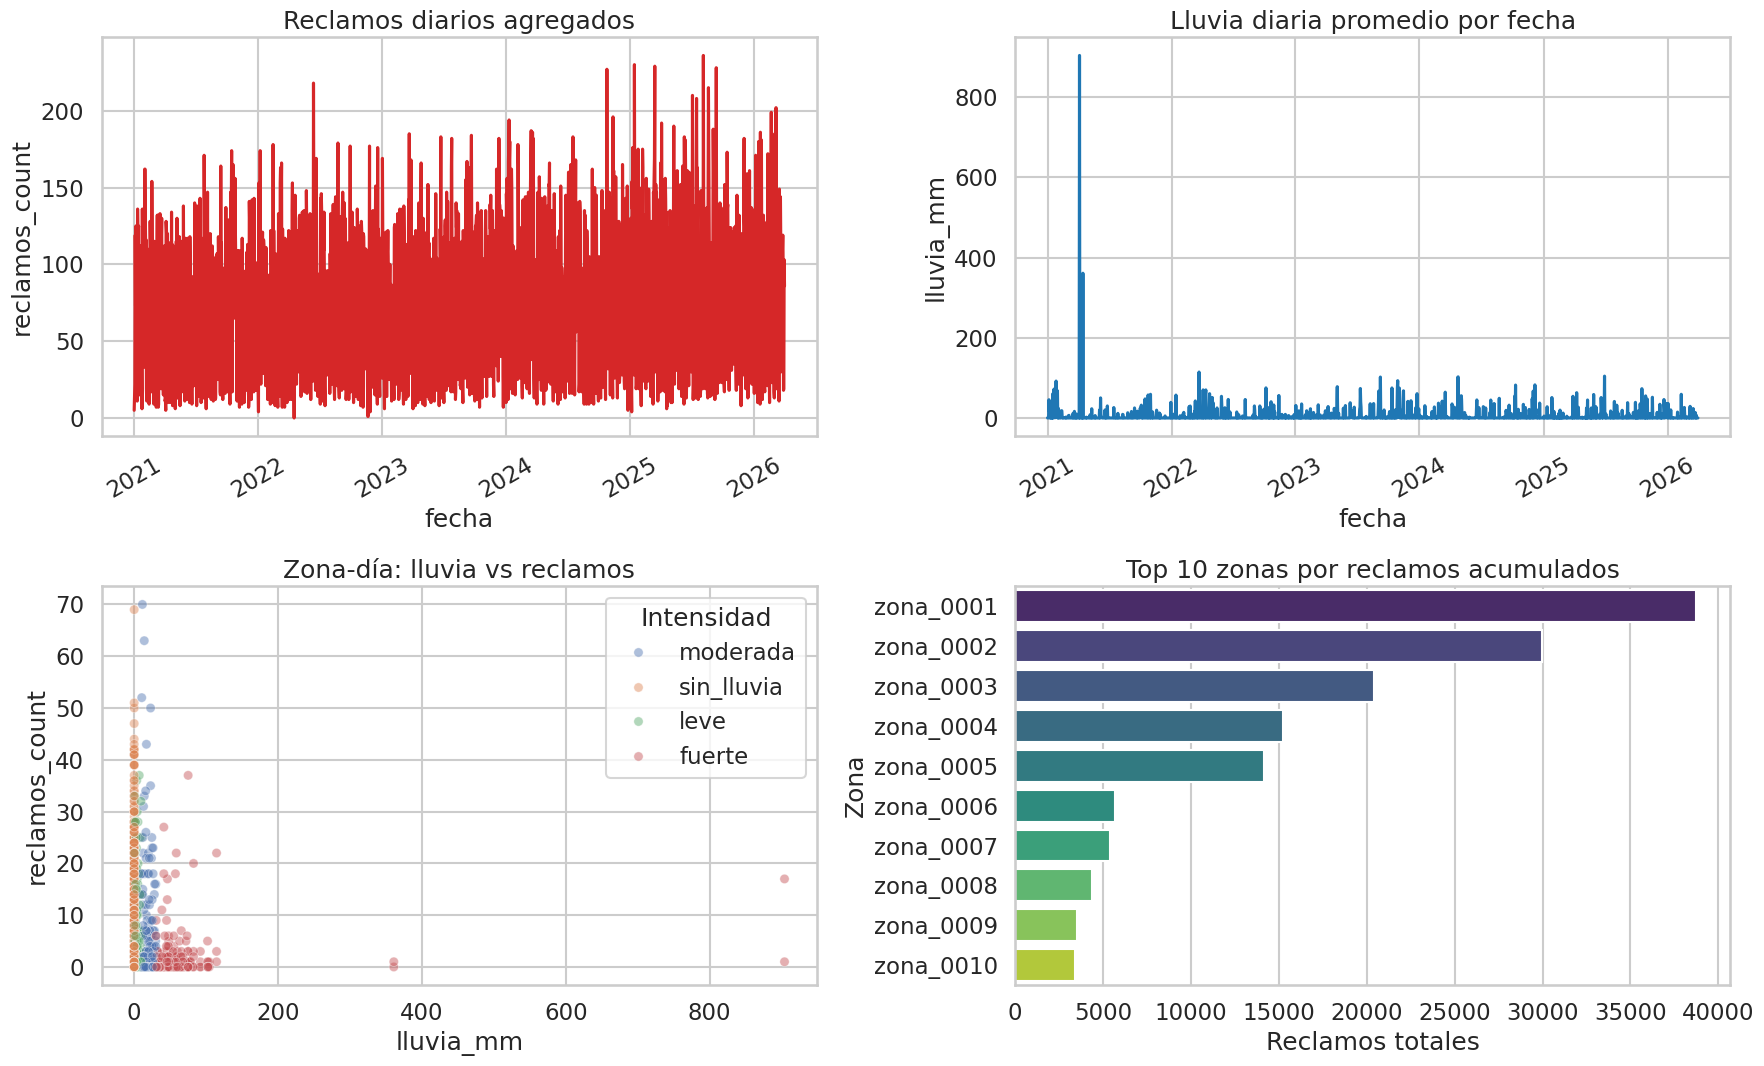

### Impacto promedio por intensidad de lluvia

,lluvia_intensidad,zona_dias,reclamos_promedio,costo_promedio_ars,tiempo_promedio_min
3,sin_lluvia,52979,2.03,"75,216.76",146.09
1,leve,11555,2.27,"84,337.71",163.46
2,moderada,6752,2.34,"87,053.24",168.86
0,fuerte,4208,2.27,"85,524.55",164.92


### Perfil categórico de reclamos zonificados

,column,value,count
0,servicio_normalizado,ENERGIA,66703
1,servicio_normalizado,TV CABLE,22347
2,servicio_normalizado,TRANSMISION DE DATOS,21481
3,servicio_normalizado,AGUA POTABLE,20195
4,servicio_normalizado,ALUMBRADO PUBLICO,11180
5,servicio_normalizado,SEG. SEPELIO,2997
6,servicio_normalizado,ADICIONALES,2843
7,servicio_normalizado,FACTURAS ADICIONALES,2833
8,servicio_normalizado,SEGURO DE HOGAR,2136
9,servicio_normalizado,ENERGIA PREPAGA,1946


### Zonas líderes por volumen/costo

,zona_id,reclamos_totales,costo_total_ars,lluvia_promedio_mm
0,zona_0001,"38,748.00","1,168,961,556.79",5.85
1,zona_0002,"29,951.00","991,771,483.24",5.85
2,zona_0003,"20,435.00","641,730,705.22",5.86
3,zona_0004,"15,227.00","710,452,605.37",5.85
4,zona_0005,"14,174.00","713,007,967.63",5.86
5,zona_0006,"5,676.00","190,567,983.45",5.86
6,zona_0007,"5,387.00","215,015,947.60",5.86
7,zona_0008,"4,353.00","140,431,222.04",5.85
8,zona_0009,"3,547.00","176,397,188.91",5.86
9,zona_0010,"3,381.00","147,133,873.13",5.86


In [6]:
serie_diaria = (
    zona_diario_base.groupby('fecha', as_index=False)
    .agg(
        reclamos_count=('reclamos_count', 'sum'),
        tiempo_total_operativo_min=('tiempo_total_operativo_min', 'sum'),
        costo_total_compuesto_ars=('costo_total_compuesto_ars', 'sum'),
        lluvia_mm=('lluvia_mm', 'mean'),
    )
)

impacto_lluvia = (
    zona_diario_base.groupby('lluvia_intensidad', as_index=False)
    .agg(
        zona_dias=('zona_id', 'size'),
        reclamos_promedio=('reclamos_count', 'mean'),
        costo_promedio_ars=('costo_total_compuesto_ars', 'mean'),
        tiempo_promedio_min=('tiempo_total_operativo_min', 'mean'),
    )
)

scatter_df = zona_diario_base[[
    'lluvia_mm',
    'reclamos_count',
    'costo_total_compuesto_ars',
    'zona_id',
    'lluvia_intensidad',
]].copy()
if len(scatter_df) > 5000:
    scatter_df = scatter_df.sample(5000, random_state=42)

top_zonas = (
    zona_diario_base.groupby('zona_id', as_index=False)
    .agg(
        reclamos_totales=('reclamos_count', 'sum'),
        costo_total_ars=('costo_total_compuesto_ars', 'sum'),
        lluvia_promedio_mm=('lluvia_mm', 'mean'),
    )
    .sort_values(['reclamos_totales', 'costo_total_ars'], ascending=False, kind='stable')
    .head(10)
)

fig, axes = plt.subplots(2, 2, figsize=(18, 11))

sns.lineplot(data=serie_diaria, x='fecha', y='reclamos_count', ax=axes[0, 0], color='tab:red')
axes[0, 0].set_title('Reclamos diarios agregados')
axes[0, 0].tick_params(axis='x', rotation=30)

sns.lineplot(data=serie_diaria, x='fecha', y='lluvia_mm', ax=axes[0, 1], color='tab:blue')
axes[0, 1].set_title('Lluvia diaria promedio por fecha')
axes[0, 1].tick_params(axis='x', rotation=30)

sns.scatterplot(
    data=scatter_df,
    x='lluvia_mm',
    y='reclamos_count',
    hue='lluvia_intensidad',
    alpha=0.45,
    s=45,
    ax=axes[1, 0],
)
axes[1, 0].set_title('Zona-día: lluvia vs reclamos')
axes[1, 0].legend(title='Intensidad', loc='upper right')

sns.barplot(data=top_zonas, x='reclamos_totales', y='zona_id', ax=axes[1, 1], palette='viridis')
axes[1, 1].set_title('Top 10 zonas por reclamos acumulados')
axes[1, 1].set_xlabel('Reclamos totales')
axes[1, 1].set_ylabel('Zona')

plt.tight_layout()
plt.show()

display(Markdown('### Impacto promedio por intensidad de lluvia'))
display(impacto_lluvia.sort_values('zona_dias', ascending=False, kind='stable'))

display(Markdown('### Perfil categórico de reclamos zonificados'))
display(categorical_profile(
    reclamos_zonificados,
    columns=['servicio_normalizado', 'localidad', 'zona_id'],
    top_n=10,
))

display(Markdown('### Zonas líderes por volumen/costo'))
display(top_zonas)


## 6. Vista geográfica simple por centroides

Una vista espacial básica ayuda a defender que la demanda no está distribuida de manera homogénea. En vez de dejar los centroides en un scatter plano, acá se embebe un mapa Folium liviano para ubicar cada zona en contexto real.

- **Cada círculo** representa el centroide de una zona.
- **El radio** crece con los reclamos acumulados.
- **El color** ordena el costo compuesto total, para distinguir zonas más exigentes operativamente.
- **Tooltip y popup** resumen zona, servicio principal, días observados, reclamos y costo.


In [7]:
zone_map_df = prepare_zone_map_dataset(zona_diario_base)
display(zone_map_df.sort_values('reclamos_totales', ascending=False, kind='stable').head(10))

if not zone_map_df.empty:
    zone_map_df = zone_map_df.copy()

    def scale_value(value, min_value, max_value, out_min, out_max):
        if pd.isna(value):
            return out_min
        if min_value == max_value:
            return (out_min + out_max) / 2
        return out_min + (float(value - min_value) / float(max_value - min_value)) * (out_max - out_min)

    def color_for_cost(value, min_value, max_value):
        palette = ['#dbeafe', '#93c5fd', '#60a5fa', '#2563eb', '#1d4ed8']
        if min_value == max_value:
            return palette[-1]
        normalized = float(value - min_value) / float(max_value - min_value)
        index = min(int(normalized * len(palette)), len(palette) - 1)
        return palette[index]

    reclamos_min = float(zone_map_df['reclamos_totales'].min())
    reclamos_max = float(zone_map_df['reclamos_totales'].max())
    costo_min = float(zone_map_df['costo_total_compuesto_ars'].min())
    costo_max = float(zone_map_df['costo_total_compuesto_ars'].max())

    center_lat = float(zone_map_df['lat'].mean())
    center_lon = float(zone_map_df['lon'].mean())

    mapa_zonas = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=11,
        tiles='OpenStreetMap',
        control_scale=True,
    )

    cluster_layer = MarkerCluster(
        name='Centroides de zona',
        options={
            'disableClusteringAtZoom': 12,
            'showCoverageOnHover': False,
            'spiderfyOnMaxZoom': True,
        },
    ).add_to(mapa_zonas)

    bounds = []
    for _, row in zone_map_df.sort_values('reclamos_totales', ascending=False, kind='stable').iterrows():
        lat = float(row['lat'])
        lon = float(row['lon'])
        reclamos = float(row['reclamos_totales'])
        costo = float(row['costo_total_compuesto_ars'])
        radius = scale_value(reclamos, reclamos_min, reclamos_max, 6, 22)
        color = color_for_cost(costo, costo_min, costo_max)
        popup_html = f"""
        <div style='min-width: 220px;'>
            <strong>{row['zona_id']}</strong><br>
            Servicio principal: {row['servicio_principal']}<br>
            Reclamos acumulados: {int(reclamos):,}<br>
            Costo total compuesto: ARS {costo:,.0f}<br>
            Días observados: {int(row['dias']):,}<br>
            Centroide: ({lat:.4f}, {lon:.4f})
        </div>
        """.strip()
        tooltip = (
            f"{row['zona_id']} · reclamos {int(reclamos):,} · "
            f"costo ARS {costo:,.0f}"
        )

        folium.CircleMarker(
            location=[lat, lon],
            radius=radius,
            color='#1f2937',
            weight=1,
            fill=True,
            fill_color=color,
            fill_opacity=0.75,
            tooltip=tooltip,
            popup=folium.Popup(popup_html, max_width=280),
        ).add_to(cluster_layer)
        bounds.append([lat, lon])

    if bounds:
        mapa_zonas.fit_bounds(bounds, padding=(20, 20))

    folium.LayerControl(collapsed=False).add_to(mapa_zonas)

    display(Markdown(
        '**Lectura rápida:** radios más grandes indican mayor volumen acumulado de reclamos; tonos más intensos señalan zonas con mayor costo compuesto total.'
    ))
    display(mapa_zonas)
else:
    display(Markdown('No hay centroides disponibles para la vista geográfica.'))


,zona_id,lat,lon,reclamos_totales,costo_total_compuesto_ars,servicio_principal,dias
0,zona_0001,-26.57,-54.76,"38,748.00","1,168,961,556.79",ENERGIA,1916
1,zona_0002,-26.57,-54.77,"29,951.00","991,771,483.24",ENERGIA,1916
2,zona_0003,-26.58,-54.74,"20,435.00","641,730,705.22",ENERGIA,1915
3,zona_0004,-26.47,-54.71,"15,227.00","710,452,605.37",ENERGIA,1916
4,zona_0005,-26.71,-54.81,"14,174.00","713,007,967.63",ENERGIA,1915
5,zona_0006,-26.55,-54.75,"5,676.00","190,567,983.45",ENERGIA,1913
6,zona_0007,-26.65,-54.75,"5,387.00","215,015,947.60",ENERGIA,1913
7,zona_0008,-26.57,-54.73,"4,353.00","140,431,222.04",ENERGIA,1916
8,zona_0009,-26.72,-54.72,"3,547.00","176,397,188.91",ENERGIA,1915
9,zona_0010,-26.54,-54.66,"3,381.00","147,133,873.13",ENERGIA,1915


**Lectura rápida:** radios más grandes indican mayor volumen acumulado de reclamos; tonos más intensos señalan zonas con mayor costo compuesto total.

## 7. Del reclamo limpio al dataset supervisado

Este es el corazón del relato del TP. Lo importante no es solo que existan varios artefactos, sino que cada uno tenga un rol claro:

1. **`reclamos_clean`** asegura validez temporal/geográfica.
2. **`reclamos_zonificados`** agrega contexto espacial y operativo por reclamo.
3. **`zona_diario_base`** cambia la unidad analítica a **zona-fecha** y retiene días sin reclamos para no romper el historial.
4. **`zona_diario_supervisado`** suma features temporales y targets futuros usando únicamente información pasada.


In [8]:
display(preparation_trace(zona_diario_base, zona_diario_supervisado))

stage_story = pd.DataFrame([
    {
        'dataset': 'reclamos_clean',
        'rows': len(reclamos_clean),
        'columns': len(reclamos_clean.columns),
        'unidad_analitica': 'reclamo',
        'aporte': 'reclamo válido en fecha y geografía',
    },
    {
        'dataset': 'reclamos_zonificados',
        'rows': len(reclamos_zonificados),
        'columns': len(reclamos_zonificados.columns),
        'unidad_analitica': 'reclamo',
        'aporte': 'zona, distancia, traslado, resolución y costo compuesto',
    },
    {
        'dataset': 'zona_diario_base',
        'rows': len(zona_diario_base),
        'columns': len(zona_diario_base.columns),
        'unidad_analitica': 'zona-fecha',
        'aporte': 'agregación diaria completa + lluvia + días sin reclamos',
    },
    {
        'dataset': 'zona_diario_supervisado',
        'rows': len(zona_diario_supervisado),
        'columns': len(zona_diario_supervisado.columns),
        'unidad_analitica': 'zona-fecha',
        'aporte': 'lags, rolling means y targets t+1',
    },
])
display(stage_story)

feature_inventory = supervised_feature_inventory(zona_diario_base, zona_diario_supervisado)
feature_family_summary = (
    feature_inventory.groupby(['feature_family', 'introduced_in_supervised'], as_index=False)
    .agg(columns=('column', 'count'), avg_coverage=('coverage', 'mean'))
    .sort_values(['introduced_in_supervised', 'feature_family'], ascending=[False, True], kind='stable')
)

display(Markdown('### Familias de features en el dataset supervisado'))
display(feature_family_summary)

display(Markdown('### Nuevas columnas incorporadas en `zona_diario_supervisado`'))
display(feature_inventory.loc[feature_inventory['introduced_in_supervised']].head(30))

sample_columns = [
    'zona_id',
    'fecha',
    'reclamos_count',
    'reclamos_count_lag_1',
    'reclamos_count_roll_7_mean',
    'lluvia_mm',
    'lluvia_mm_lag_1',
    'y_reclamos_t+1',
    'y_tiempo_t+1_min',
    'y_costo_t+1_ars',
]
existing_sample_columns = [column for column in sample_columns if column in final_dataset.columns]

display(Markdown('### Ejemplo de fila lista para modelado'))
display(final_dataset[existing_sample_columns].head(10))


,step,rows,columns,detail
0,base_dataset,75494,49,Calendario zona-fecha consolidado con reclamos...
1,feature_engineering_supervisado,75494,73,"Se agregan 24 columnas nuevas: lags, rolling m..."
2,rows_with_target_t+1,75451,3,Filas listas para baseline/modelado posterior ...


,dataset,rows,columns,unidad_analitica,aporte
0,reclamos_clean,159030,15,reclamo,reclamo válido en fecha y geografía
1,reclamos_zonificados,159030,46,reclamo,"zona, distancia, traslado, resolución y costo ..."
2,zona_diario_base,75494,49,zona-fecha,agregación diaria completa + lluvia + días sin...
3,zona_diario_supervisado,75494,73,zona-fecha,"lags, rolling means y targets t+1"


### Familias de features en el dataset supervisado

,feature_family,introduced_in_supervised,columns,avg_coverage
1,base_feature,True,1,1.00
3,lag,True,10,1.00
4,rolling,True,10,1.00
5,target,True,3,1.00
0,base_feature,False,23,0.94
2,calendar_or_key,False,7,1.00
6,weather,False,7,0.98
7,zone_or_claims,False,12,1.00


### Nuevas columnas incorporadas en `zona_diario_supervisado`

,column,feature_family,introduced_in_supervised,nulls,coverage
72,target_available_t+1,base_feature,True,0,1.00
57,costo_total_compuesto_ars_lag_1,lag,True,43,1.00
58,costo_total_compuesto_ars_lag_7,lag,True,301,1.00
65,lluvia_mm_lag_1,lag,True,43,1.00
66,lluvia_mm_lag_7,lag,True,301,1.00
49,reclamos_count_lag_1,lag,True,43,1.00
50,reclamos_count_lag_7,lag,True,301,1.00
53,tiempo_total_operativo_min_lag_1,lag,True,43,1.00
54,tiempo_total_operativo_min_lag_7,lag,True,301,1.00
61,traslado_min_total_lag_1,lag,True,43,1.00


### Ejemplo de fila lista para modelado

,zona_id,fecha,reclamos_count,reclamos_count_lag_1,reclamos_count_roll_7_mean,lluvia_mm,lluvia_mm_lag_1,y_reclamos_t+1,y_tiempo_t+1_min,y_costo_t+1_ars
0,zona_0001,2021-01-01,1.00,NaN,NaN,0.00,NaN,3.00,194.62,"91,349.33"
1,zona_0001,2021-01-02,3.00,1.00,NaN,0.00,0.00,12.00,760.12,"353,667.34"
2,zona_0001,2021-01-03,12.00,3.00,NaN,0.00,0.00,26.00,"1,664.25","779,101.65"
3,zona_0001,2021-01-04,26.00,12.00,5.33,5.50,0.00,11.00,700.48,"327,122.45"
4,zona_0001,2021-01-05,11.00,26.00,10.50,45.50,5.50,30.00,"1,886.45","877,197.69"
5,zona_0001,2021-01-06,30.00,11.00,10.60,16.50,45.50,22.00,"1,405.32","656,985.30"
6,zona_0001,2021-01-07,22.00,30.00,13.83,15.80,16.50,17.00,"1,064.87","494,419.97"
7,zona_0001,2021-01-08,17.00,22.00,15.00,0.00,15.80,7.00,456.40,"215,506.45"
8,zona_0001,2021-01-09,7.00,17.00,17.29,5.00,0.00,2.00,131.73,"62,307.32"
9,zona_0001,2021-01-10,2.00,7.00,17.86,0.00,5.00,40.00,"2,574.97","1,207,724.81"


## 8. Cierre: dataset final listo para modelado posterior

La salida de esta notebook no es un modelo; es una **base supervisada defendible**. El criterio de “listo para modelado” queda explicitado en checks concretos: eje temporal homogéneo, targets disponibles, ausencia de duplicados clave y features temporales construidas sin mirar el futuro.


In [9]:
final_summary = pd.DataFrame([
    {'metric': 'rows_ready_for_modeling', 'value': int(len(final_dataset))},
    {'metric': 'zones', 'value': int(final_dataset['zona_id'].nunique())},
    {'metric': 'date_min', 'value': pd.to_datetime(final_dataset['fecha']).min().date()},
    {'metric': 'date_max', 'value': pd.to_datetime(final_dataset['fecha']).max().date()},
    {'metric': 'feature_columns', 'value': int(len(final_dataset.columns))},
    {'metric': 'target_rows_missing', 'value': int(final_dataset['y_reclamos_t+1'].isna().sum())},
])

readiness_checks = pd.DataFrame([
    {'check': 'clave zona-fecha sin duplicados', 'status': 'ok' if int(final_dataset.duplicated(['zona_id', 'fecha']).sum()) == 0 else 'revisar'},
    {'check': 'targets disponibles en dataset final', 'status': 'ok' if int(final_dataset['y_reclamos_t+1'].isna().sum()) == 0 else 'revisar'},
    {'check': 'features con rezagos presentes', 'status': 'ok' if 'reclamos_count_lag_1' in final_dataset.columns else 'revisar'},
    {'check': 'lluvia integrada en base supervisada', 'status': 'ok' if 'lluvia_mm' in final_dataset.columns else 'revisar'},
])

next_step_checklist = pd.DataFrame([
    {'next_step': 'Definir split temporal de entrenamiento/validación/test', 'why_it_matters': 'Evita leakage y respeta causalidad temporal.'},
    {'next_step': 'Seleccionar subset de features y targets por baseline', 'why_it_matters': 'No todas las variables son necesarias para el primer experimento.'},
    {'next_step': 'Escalar/normalizar solo si el modelo elegido lo necesita', 'why_it_matters': 'La preparación debe depender del algoritmo, no al revés.'},
    {'next_step': 'Diseñar métricas acordes al objetivo operativo', 'why_it_matters': 'Predicción útil > métrica linda pero irrelevante.'},
])

display(Markdown('### Resumen final'))
display(final_summary)

display(Markdown('### Checklist de readiness'))
display(readiness_checks)

display(Markdown('### Qué faltaría antes de entrenar'))
display(next_step_checklist)

display(Markdown('### Vista rápida del dataset final'))
display(final_dataset.head())


### Resumen final

,metric,value
0,rows_ready_for_modeling,75451
1,zones,43
2,date_min,2021-01-01
3,date_max,2026-03-30
4,feature_columns,73
5,target_rows_missing,0


### Checklist de readiness

,check,status
0,clave zona-fecha sin duplicados,ok
1,targets disponibles en dataset final,ok
2,features con rezagos presentes,ok
3,lluvia integrada en base supervisada,ok


### Qué faltaría antes de entrenar

,next_step,why_it_matters
0,Definir split temporal de entrenamiento/valida...,Evita leakage y respeta causalidad temporal.
1,Seleccionar subset de features y targets por b...,No todas las variables son necesarias para el ...
2,Escalar/normalizar solo si el modelo elegido l...,"La preparación debe depender del algoritmo, no..."
3,Diseñar métricas acordes al objetivo operativo,Predicción útil > métrica linda pero irrelevante.


### Vista rápida del dataset final

,zona_id,fecha,reclamos_count,reclamos_unicos,sedes_unicas,servicios_unicos,localidades_unicas,destinos_unicos,distance_km_total,traslado_min_total,traslado_min_promedio,resolucion_base_min_total,tiempo_total_operativo_min,combustible_litros_total,costo_operativo_total_ars,costo_resolucion_base_ars,costo_combustible_ars,costo_total_compuesto_ars,reclamos_agua_cloacas,reclamos_energia,reclamos_tv_internet,zona_sede_principal,zona_servicio_principal,zona_localidad_principal,sedes_unicas_zona,servicios_unicos_zona,cluster_root,zona_destinos_count,zona_reclamos_total,centroid_lat,centroid_lon,zona_diameter_km,zona_radius_from_centroid_km,approx_target_diameter_km,dbscan_like_eps_km,cluster_method,diameter_exceeds_target,has_claims,lluvia_mm,llovio,lluvia_status,observacion_codigo,obs_categoria,obs_evento_intenso_flag,lluvia_intensidad,day_of_week,month,quarter,is_weekend,reclamos_count_lag_1,reclamos_count_lag_7,reclamos_count_roll_7_mean,reclamos_count_roll_28_mean,tiempo_total_operativo_min_lag_1,tiempo_total_operativo_min_lag_7,tiempo_total_operativo_min_roll_7_mean,tiempo_total_operativo_min_roll_28_mean,costo_total_compuesto_ars_lag_1,costo_total_compuesto_ars_lag_7,costo_total_compuesto_ars_roll_7_mean,costo_total_compuesto_ars_roll_28_mean,traslado_min_total_lag_1,traslado_min_total_lag_7,traslado_min_total_roll_7_mean,traslado_min_total_roll_28_mean,lluvia_mm_lag_1,lluvia_mm_lag_7,lluvia_mm_roll_7_mean,lluvia_mm_roll_28_mean,y_reclamos_t+1,y_tiempo_t+1_min,y_costo_t+1_ars,target_available_t+1
0,zona_0001,2021-01-01,1.00,1.00,1.00,1.00,1.00,1.00,0.81,2.73,2.73,60.00,62.73,0.08,"1,446.42","27,423.00",197.15,"29,066.58",0.00,1.00,0.00,energia,ENERGIA,MONTECARLO,3,19,0,2897,38748,-26.57,-54.76,4.90,3.36,5.00,2.50,greedy diameter-constrained spatial clustering,False,True,0.00,False,observed,A,plain_a,False,sin_lluvia,4,1,1,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.00,194.62,"91,349.33",True
1,zona_0001,2021-01-02,3.00,3.00,1.00,2.00,1.00,3.00,4.95,14.62,4.87,180.00,194.62,0.49,"7,880.44","82,269.00","1,199.89","91,349.33",0.00,3.00,0.00,energia,ENERGIA,MONTECARLO,3,19,0,2897,38748,-26.57,-54.76,4.90,3.36,5.00,2.50,greedy diameter-constrained spatial clustering,False,True,0.00,False,observed,A,plain_a,False,sin_lluvia,5,1,1,True,1.00,NaN,NaN,NaN,62.73,NaN,NaN,NaN,"29,066.58",NaN,NaN,NaN,2.73,NaN,NaN,NaN,0.00,NaN,NaN,NaN,12.00,760.12,"353,667.34",True
2,zona_0001,2021-01-03,12.00,12.00,1.00,1.00,2.00,12.00,12.90,40.12,3.34,720.00,760.12,1.29,"21,463.33","329,076.00","3,128.01","353,667.34",0.00,12.00,0.00,energia,ENERGIA,MONTECARLO,3,19,0,2897,38748,-26.57,-54.76,4.90,3.36,5.00,2.50,greedy diameter-constrained spatial clustering,False,True,0.00,False,observed,A,plain_a,False,sin_lluvia,6,1,1,True,3.00,NaN,NaN,NaN,194.62,NaN,NaN,NaN,"91,349.33",NaN,NaN,NaN,14.62,NaN,NaN,NaN,0.00,NaN,NaN,NaN,26.00,"1,664.25","779,101.65",True
3,zona_0001,2021-01-04,26.00,26.00,3.00,9.00,1.00,22.00,38.05,104.25,4.01,"1,560.00","1,664.25",3.81,"56,875.56","712,998.00","9,228.09","779,101.65",4.00,14.00,8.00,energia,ENERGIA,MONTECARLO,3,19,0,2897,38748,-26.57,-54.76,4.90,3.36,5.00,2.50,greedy diameter-constrained spatial clustering,False,True,5.50,True,observed,A•,evento_intenso,True,leve,0,1,1,False,12.00,NaN,5.33,NaN,760.12,NaN,339.16,NaN,"353,667.34",NaN,"158,027.75",NaN,40.12,NaN,19.16,NaN,0.00,NaN,0.00,NaN,11.00,700.48,"327,122.45",True
4,zona_0001,2021-01-05,11.00,11.00,3.00,6.00,1.00,10.00,14.36,40.48,3.68,660.00,700.48,1.44,"21,986.18","301,653.00","3,483.27","327,122.45",2.00,7.00,2.00,energia,ENERGIA,MONTECARLO,3,19,0,2897,38748,-26.57,-54.76,4.90,3.36,5.00,2.50,greedy diameter-constrained spatial clustering,False,True,45.50,True,observed,/B•,evento_intenso,True,fuerte,1,1,1,False,26.00,NaN,10.50,NaN,"1,664.25",NaN,670.43,NaN,"779,101.65",NaN,"313,296.22",NaN,104.25,NaN,40.43,NaN,5.50,NaN,1.38,NaN,30.00,"1,886.45","877,197.69",True
